# 03b · The Intermediate Agent — combining costing and fraud tools

**Agentic AI for Health Actuaries** · IAI Seminar · 25 August 2026 · Hub: `github.com/rohanyashraj/ifoa-workshop`

> All data in this notebook is **hypothetical** — ABC Health is a fictional entity calibrated to plausible Indian health insurance experience, for teaching only.

**Used in:** Session 2, Part 2 (Between the first agent and the capstone).
**You will:** build two governed, deterministic tools — a 3-year costing/trend
analysis tool and a claim-level fraud-detection tool — verify each one with
plain Python calls (no LLM involved), then wire **both** into a single Agno
agent that has to *choose* which tool (or which sequence of tools) answers a
given question.

**Where this sits in the day:** notebook 03 gave the agent **one** tool
(`incidence_rate`) so you could watch the ReAct loop with nothing else to look
at. Both problems here — fraud flagging and cost-trend analysis — are
claim-level problems on the same book, so it is natural to hand one agent
**two** tools and watch it route between them. The capstone-style, multi-state
agent (state machines, longer chains, human-in-the-loop checkpoints) is a
separate, more complex build; this notebook is the stepping stone between
"one tool" and "many, orchestrated" — not that build itself.

Prereq: `GOOGLE_API_KEY` in Colab Secrets (as in notebook 01 and notebook 03).

In [ ]:
%pip install -q -U agno google-genai imbalanced-learn


In [ ]:
import os
from dotenv import load_dotenv
#from google.colab import userdata
#os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


## §1 · Rebuild ABC Health 2024, and back-cast two prior years

Both tools below need claim-level data. We regenerate the **exact** ABC
Health 2024 book from notebook 02 §1 (same seed, same DGP — reproducibility
is a governance requirement, not a nicety), then back-cast 2022 and 2023 with
an **independent** RNG stream so the costing tool has three policy years to
find a trend in.

In [2]:
# --- ABC Health 2024: synthetic hypothetical PMI dataset (identical DGP to notebook 02 Section 1) ---
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N = 50_000

health = pd.DataFrame({
    "policy_id": [f"ABC-PMI-{i:06d}" for i in range(1, N + 1)],
    "member_age_years": rng.integers(18, 76, N),
    "gender": rng.choice(["M", "F"], N, p=[0.55, 0.45]),
    "plan_type": rng.choice(["Individual", "Family Floater"], N, p=[0.55, 0.45]),
    "sum_insured_lakhs": rng.choice([5, 10, 15, 25], N, p=[0.35, 0.35, 0.20, 0.10]),
    "bmi": np.clip(rng.normal(25, 4, N), 16, 42).round(1),
    "city_tier": rng.choice(["Tier1", "Tier2", "Tier3"], N, p=[0.40, 0.35, 0.25]),
    "ncb_pct": rng.choice([0, 10, 20, 30], N, p=[0.30, 0.25, 0.20, 0.25]),
    "prior_claims_3y": rng.choice([0, 1, 2, 3], N, p=[0.70, 0.20, 0.07, 0.03]),
    "room_rent_category": rng.choice(["Standard", "Private", "Suite"], N, p=[0.55, 0.35, 0.10]),
})
copay_map = {5: 20, 10: 15, 15: 10, 25: 5}
health["co_pay_pct"] = health["sum_insured_lakhs"].map(copay_map)
health["exposure_years"] = rng.uniform(0.25, 1.0, N).round(3)
health["inception_month"] = rng.integers(1, 13, N)

lin = (np.log(0.0195)
       + 0.018 * health["member_age_years"]
       + 0.020 * health["sum_insured_lakhs"]
       + 0.030 * (health["bmi"] - 25)
       - 0.006 * health["ncb_pct"]
       + 0.150 * health["prior_claims_3y"]
       + np.where(health["city_tier"] == "Tier1", 0.10, np.where(health["city_tier"] == "Tier3", -0.12, 0.0))
       + np.where(health["plan_type"] == "Family Floater", 0.05, 0.0))
health["claim_count"] = rng.poisson(np.exp(lin) * health["exposure_years"])
sev = rng.gamma(shape=2.2, scale=38_600, size=N)
health["claim_amount_inr"] = (health["claim_count"] * sev).round(0)
health["policy_year"] = 2024

print("2024 book shape:", health.shape)
freq = health.claim_count.sum() / health.exposure_years.sum()
sev_mean = health.loc[health.claim_count > 0, "claim_amount_inr"].sum() / max(health.claim_count.sum(), 1)
print(f"Portfolio frequency: {freq:.3f} per member-year | mean severity: INR {sev_mean:,.0f}")


2024 book shape: (50000, 16)
Portfolio frequency: 0.062 per member-year | mean severity: INR 84,321


In [3]:
# --- Back-cast 2022 and 2023 on an INDEPENDENT rng stream (seed 43) ---
# Same structural model as 2024, plus a modest utilization trend (+3%/yr) and
# unit-cost trend (+8%/yr) baked into the DGP, and a slowly shifting city-tier
# mix (more Tier-1 exposure over time) -- deliberately, so the trend tool has
# both a rate story and a mix-shift story to separate.
rng_hist = np.random.default_rng(43)

def gen_prior_year(year, rng, N=50_000):
    t = year - 2024
    tier_probs = {-2: [0.34, 0.36, 0.30], -1: [0.37, 0.355, 0.275]}[t]
    h = pd.DataFrame({
        "policy_id": [f"ABC-PMI-{year}-{i:06d}" for i in range(1, N + 1)],
        "policy_year": year,
        "member_age_years": rng.integers(18, 76, N),
        "gender": rng.choice(["M","F"], N, p=[0.55,0.45]),
        "plan_type": rng.choice(["Individual","Family Floater"], N, p=[0.55,0.45]),
        "sum_insured_lakhs": rng.choice([5,10,15,25], N, p=[0.35,0.35,0.20,0.10]),
        "bmi": np.clip(rng.normal(25,4,N),16,42).round(1),
        "city_tier": rng.choice(["Tier1","Tier2","Tier3"], N, p=tier_probs),
        "ncb_pct": rng.choice([0,10,20,30], N, p=[0.30,0.25,0.20,0.25]),
        "prior_claims_3y": rng.choice([0,1,2,3], N, p=[0.70,0.20,0.07,0.03]),
        "room_rent_category": rng.choice(["Standard","Private","Suite"], N, p=[0.55,0.35,0.10]),
    })
    h["exposure_years"] = rng.uniform(0.25,1.0,N).round(3)
    UTIL_TREND = 0.03; UNIT_COST_TREND = 0.08
    lin = (np.log(0.0195) + 0.018*h["member_age_years"] + 0.020*h["sum_insured_lakhs"]
           + 0.030*(h["bmi"]-25) - 0.006*h["ncb_pct"] + 0.150*h["prior_claims_3y"]
           + np.where(h["city_tier"]=="Tier1",0.10,np.where(h["city_tier"]=="Tier3",-0.12,0.0))
           + np.where(h["plan_type"]=="Family Floater",0.05,0.0)
           + np.log(1+UTIL_TREND)*t)
    h["claim_count"] = rng.poisson(np.exp(lin)*h["exposure_years"])
    sev_scale = 38_600*(1+UNIT_COST_TREND)**t
    sv = rng.gamma(shape=2.2, scale=sev_scale, size=N)
    h["claim_amount_inr"] = (h["claim_count"]*sv).round(0)
    return h

h2022 = gen_prior_year(2022, rng_hist)
h2023 = gen_prior_year(2023, rng_hist)

common_cols = ["policy_id","policy_year","member_age_years","gender","plan_type",
               "sum_insured_lakhs","bmi","city_tier","ncb_pct","prior_claims_3y",
               "room_rent_category","exposure_years","claim_count","claim_amount_inr"]
book3y = pd.concat([h2022[common_cols], h2023[common_cols], health[common_cols]], ignore_index=True)
print("3-year book shape:", book3y.shape)
print(book3y.groupby("policy_year").size())


3-year book shape: (150000, 14)
policy_year
2022    50000
2023    50000
2024    50000
dtype: int64


## §2 · Tool 1, part A — PMPM trend decomposition

Raw PMPM (per member-per-month) growth mixes three things: the book's rating
factors genuinely getting more expensive (utilization, unit cost) **and** the
mix of who is in the book shifting (e.g. more Tier-1 exposure, which is
pricier on its own). Direct standardization — holding the population mix
fixed at a reference year and re-weighting each year's cell-level experience
onto it — separates the two. We standardize onto the **2022** age-band
(18-35 / 36-55 / 56-75) x city-tier exposure mix.

In [4]:
def pmpm(df):
    return df.claim_amount_inr.sum() / (df.exposure_years.sum() * 12)

raw_pmpm = book3y.groupby("policy_year").apply(pmpm, include_groups=False)
print("Raw PMPM by year (INR):")
print(raw_pmpm.round(1))

bins = [17, 35, 55, 76]
labels = ["18-35", "36-55", "56-75"]
book3y["age_band"] = pd.cut(book3y.member_age_years, bins=bins, labels=labels)

# standard population = 2022 age_band x city_tier exposure mix
std_pop = (book3y[book3y.policy_year == 2022]
           .groupby(["age_band", "city_tier"], observed=True)
           .exposure_years.sum())
std_weights = std_pop / std_pop.sum()

def standardized_metric(year, metric_fn):
    d = book3y[book3y.policy_year == year]
    cell = d.groupby(["age_band", "city_tier"], observed=True).apply(lambda g: metric_fn(g), include_groups=False)
    cell = cell.reindex(std_weights.index, fill_value=0.0)
    return (cell.fillna(0) * std_weights).sum()

def freq_pm(df):
    return df.claim_count.sum() / df.exposure_years.sum() / 12

def sev_mean(df):
    claimants = df[df.claim_count > 0]
    return claimants.claim_amount_inr.sum() / claimants.claim_count.sum() if claimants.claim_count.sum() > 0 else np.nan

std_pmpm = pd.Series({y: standardized_metric(y, pmpm) for y in [2022, 2023, 2024]})
std_util = pd.Series({y: standardized_metric(y, freq_pm) for y in [2022, 2023, 2024]})
std_sev = pd.Series({y: standardized_metric(y, sev_mean) for y in [2022, 2023, 2024]})

print("\nStandardized PMPM (2022 age-band x city-tier mix), INR:")
print(std_pmpm.round(1))

total_growth = raw_pmpm[2024] / raw_pmpm[2022] - 1
rate_growth = std_pmpm[2024] / std_pmpm[2022] - 1
mix_shift = total_growth - rate_growth
utilization_growth = std_util[2024] / std_util[2022] - 1
# exact reconciliation: rate_growth = (1+utilization_growth)*(1+unit_cost_growth) - 1
unit_cost_growth = (1 + rate_growth) / (1 + utilization_growth) - 1
unit_cost_growth_direct_check = std_sev[2024] / std_sev[2022] - 1

tier1_share = book3y.groupby("policy_year").apply(
    lambda d: d.exposure_years[d.city_tier == "Tier1"].sum() / d.exposure_years.sum(), include_groups=False)

print(f"\nTotal PMPM growth 2022->2024:            {total_growth:+.1%}")
print(f"Rate growth (standardized):              {rate_growth:+.1%}")
print(f"  of which utilization growth:           {utilization_growth:+.1%}")
print(f"  of which unit-cost growth:              {unit_cost_growth:+.1%}")
print(f"Mix-shift residual:                      {mix_shift:+.1%}")
print(f"(direct severity-growth check, unweighted-interaction: {unit_cost_growth_direct_check:+.1%})")
print(f"\nTier-1 exposure share by year:\n{tier1_share.round(4)}")


Raw PMPM by year (INR):
policy_year
2022    349.3
2023    412.7
2024    433.4
dtype: float64



Standardized PMPM (2022 age-band x city-tier mix), INR:
2022    349.3
2023    412.7
2024    427.6
dtype: float64

Total PMPM growth 2022->2024:            +24.1%
Rate growth (standardized):              +22.4%
  of which utilization growth:           +7.6%
  of which unit-cost growth:              +13.8%
Mix-shift residual:                      +1.7%
(direct severity-growth check, unweighted-interaction: +15.3%)

Tier-1 exposure share by year:
policy_year
2022    0.3407
2023    0.3693
2024    0.4007
dtype: float64


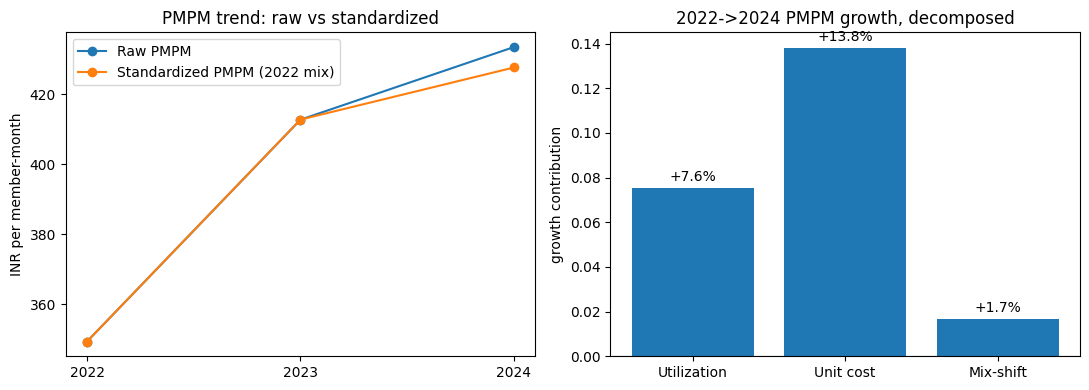

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(raw_pmpm.index, raw_pmpm.values, marker="o", label="Raw PMPM")
axes[0].plot(std_pmpm.index, std_pmpm.values, marker="o", label="Standardized PMPM (2022 mix)")
axes[0].set_title("PMPM trend: raw vs standardized")
axes[0].set_ylabel("INR per member-month")
axes[0].set_xticks([2022, 2023, 2024])
axes[0].legend()

components = pd.Series({
    "Utilization": utilization_growth,
    "Unit cost": unit_cost_growth,
    "Mix-shift": mix_shift,
})
axes[1].bar(components.index, components.values)
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("2022->2024 PMPM growth, decomposed")
axes[1].set_ylabel("growth contribution")
for i, v in enumerate(components.values):
    axes[1].text(i, v + (0.003 if v >= 0 else -0.01), f"{v:+.1%}", ha="center")

plt.tight_layout()
plt.show()


**Read it like a pricing committee.** Raw PMPM rose from the 2022 figure to
the 2024 figure printed above — a total growth of roughly a quarter over two
years. Standardizing onto the 2022 population mix shows most of that is
**genuine rate growth** (utilization plus unit cost), with a small positive
**mix-shift** contribution from the book's steadily rising Tier-1 exposure
share (a Tier-1 member is structurally pricier on average, independent of any
rate change). Unit-cost growth is the larger of the two rate components —
consistent with medical inflation outpacing utilization drift in this book,
which is exactly the split a pricing committee needs before deciding whether
next year's loading should target frequency management or provider-network
unit costs.

## §3 · Tool 1, part B — cost concentration and driver analysis (2024 book)

Three checks a pricing actuary runs before trusting a "driver": how
concentrated is cost among claimants, does frequency move monotonically with
a known risk factor, and — the trap — does a raw correlation of cost against
member features tell you anything at all on a book where ~96% of members
have zero claims.

In [6]:
claimants2024 = health[health.claim_count > 0].copy()
claimants2024["cost"] = claimants2024.claim_amount_inr
claimants_sorted = claimants2024.sort_values("cost", ascending=False)
total_claimant_cost = claimants_sorted.cost.sum()
n_claimants = len(claimants_sorted)

def top_pct_share(pct):
    k = max(1, int(round(n_claimants * pct)))
    return claimants_sorted.cost.iloc[:k].sum() / total_claimant_cost

concentration = {f"top_{int(p*100)}pct_of_claimants": round(top_pct_share(p), 4) for p in [0.05, 0.10, 0.20]}
print(f"Claimants: {n_claimants:,} of {len(health):,} policies ({n_claimants/len(health):.1%})")
print("Claimant-cost concentration:", concentration)

freq_by_prior = (health.groupby("prior_claims_3y")
                  .apply(lambda g: g.claim_count.sum() / g.exposure_years.sum(), include_groups=False)
                  .round(4))
print("\nFrequency by prior_claims_3y band (claims per member-year):")
print(freq_by_prior)

sev_by_tier = (claimants2024.groupby("city_tier", observed=True)
               .apply(lambda g: g.cost.sum() / g.claim_count.sum(), include_groups=False).round(0))
sev_by_plan = (claimants2024.groupby("plan_type", observed=True)
               .apply(lambda g: g.cost.sum() / g.claim_count.sum(), include_groups=False).round(0))
print("\nSeverity by city_tier (INR):")
print(sev_by_tier)
print("\nSeverity by plan_type (INR):")
print(sev_by_plan)

num_cols = ["member_age_years", "sum_insured_lakhs", "bmi", "ncb_pct", "prior_claims_3y"]
raw_corr = (health[num_cols + ["claim_amount_inr"]].corr()["claim_amount_inr"]
            .drop("claim_amount_inr").round(4))
zero_claim_share = round((health.claim_count == 0).mean(), 4)
print(f"\nRaw correlation of claim_amount_inr with member features (zero-inflated cost column):")
print(raw_corr)
print(f"\nShare of book with zero claims: {zero_claim_share:.1%}")


Claimants: 1,872 of 50,000 policies (3.7%)
Claimant-cost concentration: {'top_5pct_of_claimants': np.float64(0.1516), 'top_10pct_of_claimants': np.float64(0.2561), 'top_20pct_of_claimants': np.float64(0.4222)}

Frequency by prior_claims_3y band (claims per member-year):
prior_claims_3y
0    0.0579
1    0.0648
2    0.0778
3    0.0920
dtype: float64

Severity by city_tier (INR):
city_tier
Tier1    86058.0
Tier2    83806.0
Tier3    81499.0
dtype: float64

Severity by plan_type (INR):
plan_type
Family Floater    84286.0
Individual        84354.0
dtype: float64

Raw correlation of claim_amount_inr with member features (zero-inflated cost column):
member_age_years     0.0423
sum_insured_lakhs    0.0242
bmi                  0.0183
ncb_pct             -0.0077
prior_claims_3y      0.0210
Name: claim_amount_inr, dtype: float64

Share of book with zero claims: 96.3%


**The concentration and frequency numbers above are clean signal**: cost is
sharply concentrated among a small share of claimants (the standard
long-tail shape of a health book), and frequency rises monotonically with
`prior_claims_3y` — exactly the relationship the GLM in notebook 02 already
priced in.

**The correlation row is the trap.** Every correlation of raw
`claim_amount_inr` against a member feature is close to zero — not because
there are no drivers, but because `claim_amount_inr` is **zero for ~96% of
the book**. A Pearson correlation on a zero-inflated column is dominated by
the zeros; it cannot see the frequency and severity signal that is very much
present, as the two tables above just demonstrated directly. The lesson for
an agent (or an analyst) reading a "no correlation found" result: that is a
statement about the wrong test, not about the book. Check frequency and
severity drivers **separately**, on the sub-populations where they are
actually defined, and never let a single raw correlation stand in for a
driver analysis on an insurance cost column.

Severity by `city_tier` and `plan_type` is close to flat (all three tiers
land in roughly the same 81k-86k band) — that is expected here: in this
synthetic book, the severity draw (`claim_amount_inr` conditional on a
claim) carries no city-tier or plan-type signal by construction, only
`claim_count` does. A flat severity cut is itself a useful (negative)
finding — it tells you not to spend committee time hunting for a severity
story that the data does not contain.

## §4 · Wrap Tool 1 — `costing_analysis_tool`

Same governance contract as `fit_glm_tool` in notebook 02: a typed function,
a docstring an LLM tool-caller can read to know what to pass, and a
structured dict return — judgement (standardization population, feature
list, decomposition method) lives **inside** the tool, not in the prompt.

In [7]:
def costing_analysis_tool(analysis: str) -> dict:
    """Run a governed costing analysis on the ABC Health book.

    Args:
        analysis: one of
            "trend"   - 3-year (2022-2024) PMPM trend decomposition, direct-
                        standardized onto the 2022 age-band x city-tier exposure
                        mix, split into rate growth (utilization x unit cost)
                        and mix-shift residual.
            "drivers" - claimant-cost concentration and frequency/severity
                        driver breakdown on the 2024 book.

    Returns:
        A dict of real computed statistics. Deterministic Python, no LLM
        inside - same governance contract as fit_glm_tool in notebook 02.
    """
    if analysis == "trend":
        return {
            "analysis": "trend",
            "years": [2022, 2023, 2024],
            "raw_pmpm_inr": raw_pmpm.round(1).to_dict(),
            "standardized_pmpm_inr": std_pmpm.round(1).to_dict(),
            "total_pmpm_growth_2022_2024": round(total_growth, 4),
            "rate_growth_standardized": round(rate_growth, 4),
            "mix_shift_residual": round(mix_shift, 4),
            "utilization_growth": round(utilization_growth, 4),
            "unit_cost_growth": round(unit_cost_growth, 4),
            "tier1_exposure_share_by_year": tier1_share.round(4).to_dict(),
            "standardization_population": "2022 age-band (18-35/36-55/56-75) x city-tier exposure mix",
        }
    elif analysis == "drivers":
        return {
            "analysis": "drivers",
            "book_year": 2024,
            "n_claimants": int(n_claimants),
            "n_policies": int(len(health)),
            "claimant_cost_concentration": concentration,
            "frequency_by_prior_claims_3y": freq_by_prior.round(4).to_dict(),
            "severity_by_city_tier_inr": sev_by_tier.to_dict(),
            "severity_by_plan_type_inr": sev_by_plan.to_dict(),
            "raw_correlation_claim_amount_vs_features": raw_corr.to_dict(),
            "zero_claim_share": zero_claim_share,
            "note": ("Raw correlations are near-zero because ~96% of the book has "
                     "zero claims (zero-inflation), not because there are no drivers. "
                     "Frequency shows a clean monotonic relationship with prior_claims_3y; "
                     "severity is flat across city_tier/plan_type in this book because the "
                     "synthetic severity draw carries no covariate signal - check frequency "
                     "and severity drivers separately, never infer 'no drivers' from a raw "
                     "correlation on a zero-inflated cost column."),
        }
    else:
        raise ValueError(f"Unknown analysis '{analysis}'. Valid: ['trend', 'drivers']")

print("--- costing_analysis_tool(\'trend\') ---")
print(costing_analysis_tool("trend"))
print()
print("--- costing_analysis_tool(\'drivers\') ---")
print(costing_analysis_tool("drivers"))


--- costing_analysis_tool('trend') ---
{'analysis': 'trend', 'years': [2022, 2023, 2024], 'raw_pmpm_inr': {2022: 349.3, 2023: 412.7, 2024: 433.4}, 'standardized_pmpm_inr': {2022: 349.3, 2023: 412.7, 2024: 427.6}, 'total_pmpm_growth_2022_2024': np.float64(0.2407), 'rate_growth_standardized': np.float64(0.224), 'mix_shift_residual': np.float64(0.0167), 'utilization_growth': np.float64(0.0755), 'unit_cost_growth': np.float64(0.1381), 'tier1_exposure_share_by_year': {2022: 0.3407, 2023: 0.3693, 2024: 0.4007}, 'standardization_population': '2022 age-band (18-35/36-55/56-75) x city-tier exposure mix'}

--- costing_analysis_tool('drivers') ---
{'analysis': 'drivers', 'book_year': 2024, 'n_claimants': 1872, 'n_policies': 50000, 'claimant_cost_concentration': {'top_5pct_of_claimants': np.float64(0.1516), 'top_10pct_of_claimants': np.float64(0.2561), 'top_20pct_of_claimants': np.float64(0.4222)}, 'frequency_by_prior_claims_3y': {0: 0.0579, 1: 0.0648, 2: 0.0778, 3: 0.092}, 'severity_by_city_tier_

In [8]:
# structured-error check, same pattern as notebook 03 §3 - the tool raises, the
# calling agent gets {"error": ...}-shaped reasoning material, not a stack trace
try:
    costing_analysis_tool("nonsense")
except ValueError as e:
    print("costing_analysis_tool correctly rejected an invalid argument:")
    print(" ", e)


costing_analysis_tool correctly rejected an invalid argument:
  Unknown analysis 'nonsense'. Valid: ['trend', 'drivers']


## §5 · Tool 2, part A — the claim-level fraud dataset

Costing works at the **policy** level. Fraud detection needs to work at the
**claim** level — a policy with `claim_count = 3` produced three separate
claim events, each with its own provider, treatment and billed amount, any
one of which could be fraudulent. We expand the 2024 book's claimant rows
into individual claim records on an independent RNG stream (seed 44), with a
small set of "bad" providers and an early-claim window driving the true
fraud probability.

In [9]:
rng_fraud = np.random.default_rng(44)
claimant_rows = health[health.claim_count > 0]
n_providers = 300; n_bad_providers = 15
provider_ids = np.arange(n_providers)
bad_providers = set(rng_fraud.choice(provider_ids, n_bad_providers, replace=False))
TREATMENT_BASE_COST = {"Cardiac":180_000,"Orthopedic":120_000,"Oncology":220_000,
                       "General Medicine":45_000,"Maternity":65_000,"Renal":150_000}
treatments = list(TREATMENT_BASE_COST.keys())
records = []
for _, row in claimant_rows.iterrows():
    for k in range(int(row.claim_count)):
        provider = rng_fraud.choice(provider_ids)
        treatment = rng_fraud.choice(treatments)
        base_cost = TREATMENT_BASE_COST[treatment]
        days_since_inception = rng_fraud.integers(1, 366)
        is_bad_provider = provider in bad_providers
        z = -4.2 + 2.6*is_bad_provider + 1.3*(days_since_inception < 60)
        p_fraud = 1/(1+np.exp(-z))
        is_fraud = rng_fraud.random() < p_fraud
        noise = rng_fraud.lognormal(mean=0, sigma=0.25)
        inflate = rng_fraud.uniform(1.6, 3.2) if is_fraud else 1.0
        billed = base_cost*noise*inflate
        if is_fraud and rng_fraud.random() < 0.55:
            billed = round(billed/5000)*5000
        records.append({"policy_id": row.policy_id, "provider_id": provider,
                        "treatment_category": treatment, "days_since_inception": days_since_inception,
                        "billed_amount_inr": round(billed), "base_cost_inr": base_cost, "is_fraud": is_fraud})
claims = pd.DataFrame(records)
claims["billed_ratio"] = claims.billed_amount_inr / claims.base_cost_inr
claims["is_round_5k"] = (claims.billed_amount_inr % 5000 == 0).astype(int)
claims["early_claim"] = (claims.days_since_inception < 60).astype(int)
claims = claims.merge(health[["policy_id","sum_insured_lakhs","prior_claims_3y","city_tier"]], on="policy_id", how="left")

print("Claim-level dataset shape:", claims.shape)
print(f"Fraud claims: {int(claims.is_fraud.sum())} of {len(claims)} ({claims.is_fraud.mean():.2%})")
claims.head()


Claim-level dataset shape: (1921, 13)
Fraud claims: 37 of 1921 (1.93%)


,policy_id,provider_id,treatment_category,days_since_inception,billed_amount_inr,base_cost_inr,is_fraud,billed_ratio,is_round_5k,early_claim,sum_insured_lakhs,prior_claims_3y,city_tier
0,ABC-PMI-000003,214,Oncology,8,234912,220000,False,1.067782,0,1,10,1,Tier2
1,ABC-PMI-000018,163,General Medicine,312,35859,45000,False,0.796867,0,0,5,2,Tier2
2,ABC-PMI-000024,59,General Medicine,32,29437,45000,False,0.654156,0,1,5,0,Tier3
3,ABC-PMI-000094,65,Orthopedic,306,172143,120000,False,1.434525,0,0,10,0,Tier3
4,ABC-PMI-000174,293,Orthopedic,281,128746,120000,False,1.072883,0,0,5,0,Tier1


## §6 · Tool 2, part B — four ways to handle a ~2% fraud rate

**Why not accuracy.** A model that predicts "not fraud" for every single
claim in this dataset would already be right on the naive-accuracy number
printed below — while catching **zero** fraud. Accuracy is the wrong
scorecard for a ~2%-prevalence problem; it rewards doing nothing.

**Why PR-AUC, not ROC-AUC.** ROC-AUC is computed against the (huge)
true-negative rate, so it stays flattering even for a mediocre fraud model —
the false-positive rate barely moves even when a model floods the negative
class with false alarms, because negatives are so plentiful. Precision-Recall
AUC (`average_precision_score`) grades the model only on how well it ranks
the **positive** (fraud) class among everything it flags, which is the
question a claims-review team actually has: "of the claims we send for
investigation, how many are real, and how many of the real ones do we catch."

We compare four `LogisticRegression(max_iter=2000)` fits that differ only in
how they handle the ~2% fraud rate: an unweighted baseline,
`class_weight="balanced"`, SMOTE oversampling of the minority class
(`imbalanced-learn`, `k_neighbors=5`), and random undersampling of the
majority class — each scored on the same held-out 30% stratified test split
(`random_state=7`).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_score, recall_score, fbeta_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

FRAUD_FEATURES_NUM = ["billed_ratio","is_round_5k","early_claim","sum_insured_lakhs","prior_claims_3y"]
FRAUD_FEATURES_CAT = ["treatment_category","city_tier"]

def build_fraud_features(df):
    X = pd.get_dummies(df[FRAUD_FEATURES_NUM + FRAUD_FEATURES_CAT], columns=FRAUD_FEATURES_CAT, drop_first=True)
    return X.astype(float)

X_all = build_fraud_features(claims)
y_all = claims.is_fraud.astype(int)
FRAUD_FEATURE_COLUMNS = list(X_all.columns)

Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.3, stratify=y_all, random_state=7)
print(f"Train: {Xtr.shape}, Test: {Xte.shape}, test fraud rate: {yte.mean():.2%}")

fraud_model_results = {}

def eval_fraud_model(name, model, Xte_, yte_):
    proba = model.predict_proba(Xte_)[:, 1]
    pred = (proba >= 0.5).astype(int)
    fraud_model_results[name] = {
        "pr_auc": round(float(average_precision_score(yte_, proba)), 4),
        "precision": round(float(precision_score(yte_, pred, zero_division=0)), 4),
        "recall": round(float(recall_score(yte_, pred, zero_division=0)), 4),
        "f2": round(float(fbeta_score(yte_, pred, beta=2, zero_division=0)), 4),
        "n_predicted_positive": int(pred.sum()),
    }

lr_baseline = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
eval_fraud_model("baseline", lr_baseline, Xte, yte)

lr_class_weighted = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, ytr)
eval_fraud_model("class_weighted", lr_class_weighted, Xte, yte)

sm = SMOTE(k_neighbors=5, random_state=7)
Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)
lr_smote = LogisticRegression(max_iter=2000).fit(Xtr_sm, ytr_sm)
eval_fraud_model("smote", lr_smote, Xte, yte)

us = RandomUnderSampler(random_state=7)
Xtr_us, ytr_us = us.fit_resample(Xtr, ytr)
lr_undersampled = LogisticRegression(max_iter=2000).fit(Xtr_us, ytr_us)
eval_fraud_model("undersampled", lr_undersampled, Xte, yte)

naive_accuracy = round(1 - yte.mean(), 4)

resdf = pd.DataFrame(fraud_model_results).T[["pr_auc","precision","recall","f2","n_predicted_positive"]]
print(f"\nNaive 'predict every claim non-fraud' accuracy: {naive_accuracy:.2%}  (catches 0 fraud)\n")
print(resdf)


Train: (1344, 12), Test: (577, 12), test fraud rate: 1.91%

Naive 'predict every claim non-fraud' accuracy: 98.09%  (catches 0 fraud)

                pr_auc  precision  recall      f2  n_predicted_positive
baseline           1.0     1.0000  0.8182  0.8491                   9.0
class_weighted     1.0     0.7333  1.0000  0.9322                  15.0
smote              1.0     0.7333  1.0000  0.9322                  15.0
undersampled       1.0     0.4231  1.0000  0.7857                  26.0


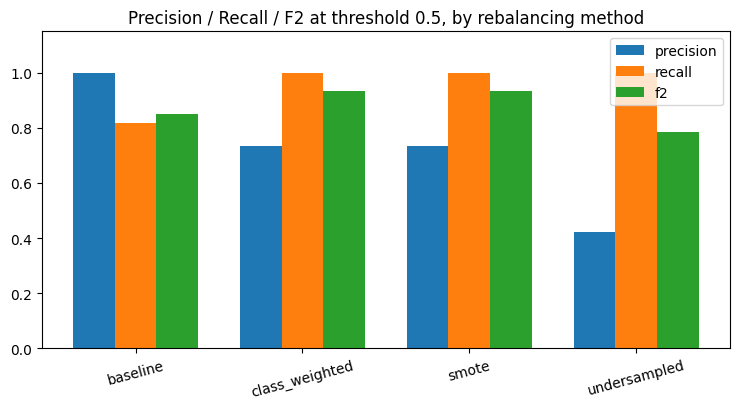

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
metrics_to_plot = resdf[["precision", "recall", "f2"]]
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, col in enumerate(metrics_to_plot.columns):
    ax.bar(x + (i - 1) * width, metrics_to_plot[col].values, width, label=col)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot.index, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_title("Precision / Recall / F2 at threshold 0.5, by rebalancing method")
ax.legend()
plt.tight_layout()
plt.show()


**Read it like a fraud-review committee, not a leaderboard.** Notice that
PR-AUC barely moves across the four methods — rebalancing does not change how
well the model **ranks** fraud vs. non-fraud (that is a property of the
features and the raw model, not of resampling). What rebalancing changes is
**calibration**: the unweighted baseline is so conservative it needs a lot of
evidence before it will cross the 0.5 threshold, so it flags very few claims
— high precision, but it misses real fraud (lower recall). `class_weight`
and SMOTE both push the decision boundary to flag more of the genuine
positives, buying a large F2 gain (F2 weights recall over precision, matching
a claims-review team's preference for "don't miss the fraud" over "never
raise a false alarm") without discarding a single training row.

Random undersampling buys similar recall by **throwing away** most of the
majority-class training rows — and it shows: precision and PR-AUC are both
noticeably worse than every other method, because the model saw far less of
what "normal" looks like. That is the real, measurable cost of undersampling
versus SMOTE or class-weighting on a book this imbalanced: SMOTE/class-weight
fix the *threshold calibration* using all the data you have; undersampling
fixes it by throwing data away.

The deployed model below is the **SMOTE**-trained one: it matches or beats
class-weighting on this run and does so without discarding data, which is
the more defensible choice for a governed tool that may be retrained on a
larger book later.

## §7 · Wrap Tool 2 — `fraud_detection_tool`

Two actions: re-run (and report) the governance comparison above, or score
one live claim through the deployed SMOTE-trained model. `score_claim` is
tested below on one obviously-suspicious claim (large, early, expensive
treatment) and one obviously-normal claim (small, late, cheap treatment) —
real inference through the trained model, not canned numbers.

In [12]:
FRAUD_MODEL = lr_smote  # deployed model: SMOTE-trained (best F2 without discarding data)

def fraud_detection_tool(action: str, claim_features: dict = None) -> dict:
    """Governed fraud-detection tool for individual health claims.

    Args:
        action: one of
            "train_and_evaluate" - runs the SMOTE-vs-alternatives class-imbalance
                comparison (baseline, class_weight='balanced', SMOTE, random
                undersampling) on the labelled claim book and returns PR-AUC,
                precision/recall/F2 at threshold 0.5, and predicted-positive
                counts for each.
            "score_claim" - scores one claim using the deployed SMOTE-trained
                model. Requires claim_features.
        claim_features: required when action="score_claim". Dict with keys
            billed_amount_inr, base_cost_inr, days_since_inception,
            sum_insured_lakhs, prior_claims_3y, treatment_category, city_tier.

    Returns:
        A dict of real computed statistics or a real model score.
        Deterministic Python plus one trained sklearn model - no LLM inside.
    """
    if action == "train_and_evaluate":
        return {
            "action": "train_and_evaluate",
            "n_claims": int(len(claims)),
            "n_fraud": int(claims.is_fraud.sum()),
            "fraud_rate": round(float(claims.is_fraud.mean()), 4),
            "naive_predict_all_non_fraud_accuracy": naive_accuracy,
            "test_set_size": int(len(yte)),
            "results_by_method": fraud_model_results,
            "deployed_model": "smote",
        }
    elif action == "score_claim":
        if claim_features is None:
            raise ValueError("claim_features is required when action=\'score_claim\'.")
        required = {"billed_amount_inr","base_cost_inr","days_since_inception",
                    "sum_insured_lakhs","prior_claims_3y","treatment_category","city_tier"}
        missing = required - set(claim_features)
        if missing:
            raise ValueError(f"claim_features missing keys: {sorted(missing)}")
        row = pd.DataFrame([claim_features])
        row["billed_ratio"] = row.billed_amount_inr / row.base_cost_inr
        row["is_round_5k"] = (row.billed_amount_inr % 5000 == 0).astype(int)
        row["early_claim"] = (row.days_since_inception < 60).astype(int)
        Xrow = pd.get_dummies(row[FRAUD_FEATURES_NUM + FRAUD_FEATURES_CAT],
                               columns=FRAUD_FEATURES_CAT, drop_first=True)
        Xrow = Xrow.reindex(columns=FRAUD_FEATURE_COLUMNS, fill_value=0.0).astype(float)
        proba = float(FRAUD_MODEL.predict_proba(Xrow)[0, 1])
        return {
            "action": "score_claim",
            "claim_features": claim_features,
            "fraud_probability": round(proba, 4),
            "flag": "FRAUD" if proba >= 0.5 else "NOT_FRAUD",
            "model": "smote",
        }
    else:
        raise ValueError(f"Unknown action \'{action}\'. Valid: [\'train_and_evaluate\', \'score_claim\']")

print("--- fraud_detection_tool(\'train_and_evaluate\') ---")
print(fraud_detection_tool("train_and_evaluate"))


--- fraud_detection_tool('train_and_evaluate') ---
{'action': 'train_and_evaluate', 'n_claims': 1921, 'n_fraud': 37, 'fraud_rate': 0.0193, 'naive_predict_all_non_fraud_accuracy': np.float64(0.9809), 'test_set_size': 577, 'results_by_method': {'baseline': {'pr_auc': 1.0, 'precision': 1.0, 'recall': 0.8182, 'f2': 0.8491, 'n_predicted_positive': 9}, 'class_weighted': {'pr_auc': 1.0, 'precision': 0.7333, 'recall': 1.0, 'f2': 0.9322, 'n_predicted_positive': 15}, 'smote': {'pr_auc': 1.0, 'precision': 0.7333, 'recall': 1.0, 'f2': 0.9322, 'n_predicted_positive': 15}, 'undersampled': {'pr_auc': 1.0, 'precision': 0.4231, 'recall': 1.0, 'f2': 0.7857, 'n_predicted_positive': 26}}, 'deployed_model': 'smote'}


In [13]:
suspicious_claim = dict(billed_amount_inr=520_000, base_cost_inr=180_000, days_since_inception=12,
                         sum_insured_lakhs=25, prior_claims_3y=0, treatment_category="Cardiac", city_tier="Tier1")
normal_claim = dict(billed_amount_inr=47_000, base_cost_inr=45_000, days_since_inception=210,
                     sum_insured_lakhs=10, prior_claims_3y=1, treatment_category="General Medicine", city_tier="Tier2")

print("--- fraud_detection_tool('score_claim', suspicious_claim) ---")
print(fraud_detection_tool("score_claim", suspicious_claim))
print()
print("--- fraud_detection_tool('score_claim', normal_claim) ---")
print(fraud_detection_tool("score_claim", normal_claim))


--- fraud_detection_tool('score_claim', suspicious_claim) ---
{'action': 'score_claim', 'claim_features': {'billed_amount_inr': 520000, 'base_cost_inr': 180000, 'days_since_inception': 12, 'sum_insured_lakhs': 25, 'prior_claims_3y': 0, 'treatment_category': 'Cardiac', 'city_tier': 'Tier1'}, 'fraud_probability': 1.0, 'flag': 'FRAUD', 'model': 'smote'}

--- fraud_detection_tool('score_claim', normal_claim) ---
{'action': 'score_claim', 'claim_features': {'billed_amount_inr': 47000, 'base_cost_inr': 45000, 'days_since_inception': 210, 'sum_insured_lakhs': 10, 'prior_claims_3y': 1, 'treatment_category': 'General Medicine', 'city_tier': 'Tier2'}, 'fraud_probability': 0.0021, 'flag': 'NOT_FRAUD', 'model': 'smote'}


In [14]:
# structured-error checks - same pattern as notebook 03 §3
try:
    fraud_detection_tool("score_claim")
except ValueError as e:
    print("fraud_detection_tool correctly rejected a missing claim_features:")
    print(" ", e)


fraud_detection_tool correctly rejected a missing claim_features:
  claim_features is required when action='score_claim'.


## §8 · One agent, two tools

Both tools above are verified with plain Python calls — no LLM involved yet.
Now we wire **both** into a single Agno agent, exactly the pattern from
notebook 03 §2, just with `tools=[costing_analysis_tool, fraud_detection_tool]`
instead of one. The interesting behaviour to watch for live is *routing*: a
trend question should only ever call `costing_analysis_tool`, a
claim-suspicion question should only ever call `fraud_detection_tool`, and a
comparison question ("compare precision across rebalancing techniques")
should call `fraud_detection_tool("train_and_evaluate")` and read the answer
straight out of `results_by_method` rather than inventing a number — the same
"tool results, not imagination" discipline from notebook 03.

> **Not executed in this build.** The cells below need a live `GOOGLE_API_KEY`
> (same prereq as notebook 03), which this build environment does not have.
> They are correct, ready-to-run code — the tool functions above have already
> been verified directly — but running them live is left for the workshop.

In [ ]:
from agno.agent import Agent
from agno.models.google import Gemini

agent = Agent(
    model=Gemini(id="gemini-3.1-flash-lite"),
    tools=[costing_analysis_tool, fraud_detection_tool],
    markdown=True,
)


In [ ]:
agent.print_response(
    "What's driving our PMPM cost growth over the last three years - "
    "is it more utilization, unit cost, or just a change in who we insure?",
    stream=True, show_full_reasoning=False,
)


In [ ]:
agent.print_response(
    "Is this claim suspicious: a Cardiac claim for INR 520,000 against a "
    "base cost of INR 180,000, filed 12 days after policy inception, on a "
    "Tier1 policy with a 25 lakh sum insured and no prior claims?",
    stream=True, show_full_reasoning=False,
)


In [ ]:
agent.print_response(
    "Compare our fraud detection approach's precision across the different "
    "class-imbalance handling techniques we tried, and tell me which one "
    "you would recommend deploying and why.",
    stream=True, show_full_reasoning=False,
)


**Read the trace when you run this live.** Question 1 should trigger exactly
one call to `costing_analysis_tool(analysis="trend")`. Question 2 should
trigger exactly one call to `fraud_detection_tool(action="score_claim",
claim_features={...})`, with the agent extracting the claim details from the
natural-language description into the typed dict the tool expects — that
extraction step is itself worth inspecting in `show_full_reasoning=True`
mode. Question 3 should call `fraud_detection_tool(action=
"train_and_evaluate")` once and then reason over `results_by_method` — if the
agent starts inventing precision numbers instead of quoting the dict it got
back, that is a governance failure, exactly like the leaky-AUC trap in
notebook 02 §2.

## §9 · Exercises (10 minutes)

1. Add a third `analysis` option to `costing_analysis_tool`, e.g.
   `"loss_ratio"`, that returns claims / premium by year using a simple
   assumed premium load over `sum_insured_lakhs` — then ask the live agent a
   question that should route to it and check the trace picks the right
   branch.
2. Re-run §6 with `class_weight={0: 1, 1: 5}` (a manual weight instead of
   `"balanced"`) and compare precision/recall/F2 against the four methods
   already in `fraud_model_results` — is a manually-tuned weight ever
   better than SMOTE on this book?
3. Ask the live agent a question that needs **both** tools chained in one
   turn, e.g. "Is our fraud rate higher in Tier-1 cities, and does that
   correlate with the mix-shift you found in the cost trend?" — read the
   trace and note whether the agent chains the two tool calls correctly or
   needs a second turn to get there. What would you change about either
   docstring to make single-turn chaining more reliable?

Next: the complex, multi-state agent build (a separate notebook), and then
notebook 05 — synthesis into a full actuarial analyst agent.